
<p style="background-color:#78F0C0;color:black;font-size:26px;text-align:center;border-radius:10px 10px;font-weight:bold;"><b>Tabular Playground Series - Nov 2021</b><span style='font-size:30px; background-color:#005266;'>&#9889;    </span></p>

<center><img src="https://github.com/Isharaneranjana/kaggle_gif/blob/main/Deep%20learning%20(1).gif?raw=true" style="width:600px;height:350px;"></center>

##  <span style='font-size:22px;'>&#128311;</span>  Introduction

<font size="4">This dataset is synthetic, but based on a real dataset and generated using a CTGAN. The original dataset deals with predicting identifying spam emails via various extracted features from the email. Although the features are anonymized, they have properties relating to real-world features. The dataset has 100 features and the response variable is a binary variable.</font>

<font size="4"><a href="https://www.kaggle.com/sisharaneranjana/model-fitting-with-normal-quantile-transformation">In my first notebook </a>I have fitted linear models, tree based models and boosting models. The highest accuracy was given by linear models. So in this notebook I will try with deep learning models to improve accuracy more.</font>

In [1]:
#importing librariaes
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

####  <span style='font-size:16px;'>&#127917;</span>  loading.. dataset

In [2]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
import warnings
warnings.filterwarnings("ignore")

/kaggle/input/tabular-playground-series-nov-2021/sample_submission.csv
/kaggle/input/tabular-playground-series-nov-2021/train.csv
/kaggle/input/tabular-playground-series-nov-2021/test.csv


In [3]:
train = pd.read_csv('/kaggle/input/tabular-playground-series-nov-2021/train.csv')
test = pd.read_csv('/kaggle/input/tabular-playground-series-nov-2021/test.csv')

print(train.shape)
print(test.shape)


(600000, 102)
(540000, 101)


In [4]:
train.head()

,id,f0,f1,f2,f3,f4,f5,f6,f7,f8,...,f91,f92,f93,f94,f95,f96,f97,f98,f99,target
0,0,0.106643,3.59437,132.8040,3.18428,0.081971,1.18859,3.73238,2.266270,2.09959,...,1.09862,0.013331,-0.011715,0.052759,0.065400,4.211250,1.97877,0.085974,0.240496,0
1,1,0.125021,1.67336,76.5336,3.37825,0.099400,5.09366,1.27562,-0.471318,4.54594,...,3.46017,0.017054,0.124863,0.154064,0.606848,-0.267928,2.57786,-0.020877,0.024719,0
2,2,0.036330,1.49747,233.5460,2.19435,0.026914,3.12694,5.05687,3.849460,1.80187,...,4.88300,0.085222,0.032396,0.116092,-0.001688,-0.520069,2.14112,0.124464,0.148209,0
3,3,-0.014077,0.24600,779.9670,1.89064,0.006948,1.53112,2.69800,4.517330,4.50332,...,3.47439,-0.017103,-0.008100,0.062013,0.041193,0.511657,1.96860,0.040017,0.044873,0
4,4,-0.003259,3.71542,156.1280,2.14772,0.018284,2.09859,4.15492,-0.038236,3.37145,...,1.91059,-0.042943,0.105616,0.125072,0.037509,1.043790,1.07481,-0.012819,0.072798,1


In [5]:
train.dtypes

id          int64
f0        float64
f1        float64
f2        float64
f3        float64
           ...   
f96       float64
f97       float64
f98       float64
f99       float64
target      int64
Length: 102, dtype: object

In [6]:
train=train.drop(['id'],1)
test=test.drop(['id'],1)

[(0, 296394), (1, 303606)]


<AxesSubplot:xlabel='target', ylabel='count'>

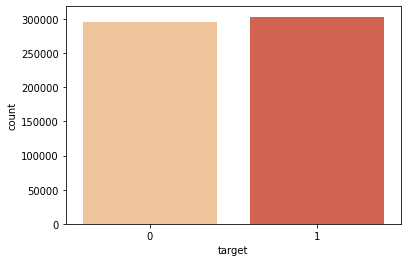

In [7]:
from collections import Counter
print(sorted(Counter(train['target']).items()))
sns.countplot(train['target'],palette='OrRd')

<AxesSubplot:>

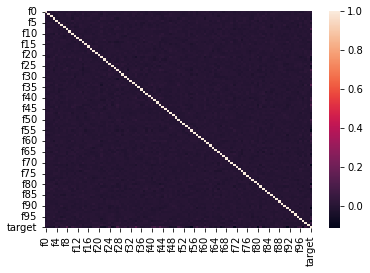

In [8]:
sns.heatmap(train.corr())

<AxesSubplot:>

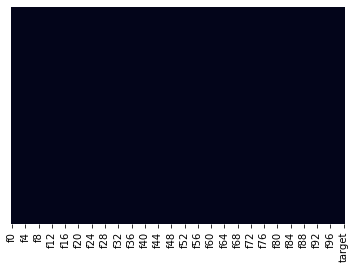

In [9]:
sns.heatmap(train.isnull(),yticklabels=False,cbar=False)

<font size="4"> no missing values, no high correlation and class labels are balanced. </font>

In [10]:
train_x=train.drop(['target'],1)
test_x=test

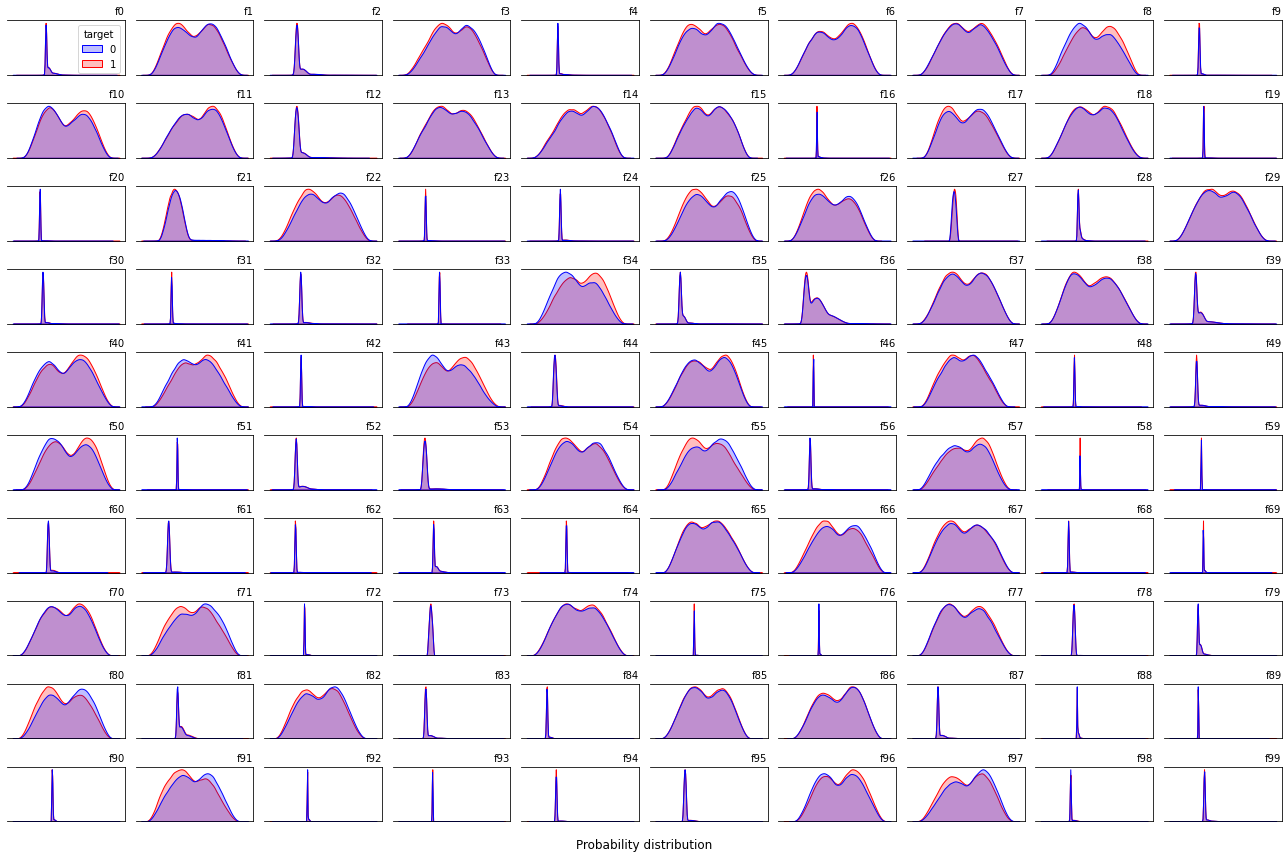

In [11]:
fig, axes = plt.subplots(10,10, figsize=(18, 12))
axes = axes.flatten()

for idx, ax in enumerate(axes):
    
    sns.kdeplot(
        data=train, ax=ax, hue='target', fill=True,
        x=f'f{idx}', palette=['blue', 'red'], legend=idx==0
    )
 
    ax.set_xticks([]); ax.set_yticks([]); ax.set_xlabel('')
    ax.set_ylabel(''); ax.spines['left'].set_visible(False)
    ax.set_title(f'f{idx}', loc='right',fontsize=10)

fig.supxlabel('Probability distribution', ha='center')
fig.tight_layout()
plt.show()

In [12]:
X= train_x
y= train['target']

In [13]:
X.head()

,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,...,f90,f91,f92,f93,f94,f95,f96,f97,f98,f99
0,0.106643,3.59437,132.8040,3.18428,0.081971,1.18859,3.73238,2.266270,2.09959,0.012330,...,0.010739,1.09862,0.013331,-0.011715,0.052759,0.065400,4.211250,1.97877,0.085974,0.240496
1,0.125021,1.67336,76.5336,3.37825,0.099400,5.09366,1.27562,-0.471318,4.54594,0.037706,...,0.135838,3.46017,0.017054,0.124863,0.154064,0.606848,-0.267928,2.57786,-0.020877,0.024719
2,0.036330,1.49747,233.5460,2.19435,0.026914,3.12694,5.05687,3.849460,1.80187,0.056995,...,0.117310,4.88300,0.085222,0.032396,0.116092,-0.001688,-0.520069,2.14112,0.124464,0.148209
3,-0.014077,0.24600,779.9670,1.89064,0.006948,1.53112,2.69800,4.517330,4.50332,0.123494,...,-0.015347,3.47439,-0.017103,-0.008100,0.062013,0.041193,0.511657,1.96860,0.040017,0.044873
4,-0.003259,3.71542,156.1280,2.14772,0.018284,2.09859,4.15492,-0.038236,3.37145,0.034166,...,0.013781,1.91059,-0.042943,0.105616,0.125072,0.037509,1.043790,1.07481,-0.012819,0.072798


In [14]:
from sklearn.preprocessing import StandardScaler
x= pd.concat([X,test_x],axis=0)
trans = StandardScaler()
trans.fit(x)
X= trans.transform(X)
test_x = trans.transform(test_x)

In [15]:
#dividing the dataset into train and test sets
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=1234)

In [16]:
!pip install autokeras
import tensorflow as tf
import autokeras as ak

     |████████████████████████████████| 166 kB 896 kB/s 
     |████████████████████████████████| 454.4 MB 14 kB/s 
     |████████████████████████████████| 462 kB 56.7 MB/s 
     |████████████████████████████████| 1.2 MB 51.2 MB/s 
     |████████████████████████████████| 4.0 MB 48.1 MB/s 
  Attempting uninstall: typing-extensions
    Found existing installation: typing-extensions 3.10.0.2
    Uninstalling typing-extensions-3.10.0.2:
      Successfully uninstalled typing-extensions-3.10.0.2
  Attempting uninstall: six
    Found existing installation: six 1.16.0
    Uninstalling six-1.16.0:
      Successfully uninstalled six-1.16.0
  Attempting uninstall: grpcio
    Found existing installation: grpcio 1.38.1
    Uninstalling grpcio-1.38.1:
      Successfully uninstalled grpcio-1.38.1
  Attempting uninstall: tensorflow-estimator
    Found existing installation: tensorflow-estimator 2.6.0
    Uninstalling tensorflow-estimator-2.6.0:
      Successfully uninstalled tensorflow-estimator-2.6.0


2022-01-28 08:04:08.073531: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: 
2022-01-28 08:04:08.074175: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.


##  <span style='font-size:22px;'>&#8987;</span> Model fitting with AutoKeras

<font size="4">The AutoKeras StructuredDataClassifier is quite flexible for the data format.it supports numpy.ndarray, pandas.DataFrame or tf.data.Dataset. The data should be two-dimensional with numerical or categorical values.For the classification labels, AutoKeras accepts both plain labels, i.e. strings or integers, and one-hot encoded encoded labels, i.e. vectors of 0s and 1s. The labels can be numpy.ndarray, pandas.DataFrame, or pandas.Series.</font>

<font size="4">By default, AutoKeras use the last 20% of training data as validation data. As shown in the example below, you can use validation_split to specify the percentage. </font>

In [17]:
clf = ak.StructuredDataClassifier(max_trials=5,seed=1234)
# Feed the structured data classifier with training data.
clf.fit(x_train, y_train, epochs=100, validation_split=0.4)
# Predict with the best model.
predicted_y = clf.predict(x_test)
# Evaluate the best model with testing data.
print(clf.evaluate(x_test, y_test))

Trial 5 Complete [00h 29m 13s]
val_accuracy: 0.7436406016349792

Best val_accuracy So Far: 0.7436406016349792
Total elapsed time: 01h 21m 23s
Epoch 1/100
15000/15000 [==============================] - 43s 3ms/step - loss: 0.6154 - accuracy: 0.6980
Epoch 2/100
15000/15000 [==============================] - 42s 3ms/step - loss: 0.5858 - accuracy: 0.7322
Epoch 3/100
15000/15000 [==============================] - 41s 3ms/step - loss: 0.5835 - accuracy: 0.7339
Epoch 4/100
15000/15000 [==============================] - 42s 3ms/step - loss: 0.5825 - accuracy: 0.7351
Epoch 5/100
15000/15000 [==============================] - 42s 3ms/step - loss: 0.5819 - accuracy: 0.7361
Epoch 6/100
15000/15000 [==============================] - 42s 3ms/step - loss: 0.5815 - accuracy: 0.7367
Epoch 7/100
15000/15000 [==============================] - 41s 3ms/step - loss: 0.5806 - accuracy: 0.7372
Epoch 8/100
15000/15000 [==============================] - 42s 3ms/step - loss: 0.5808 - accuracy: 0.7377
Epoch 9/10

2022-01-28 11:00:00.619699: W tensorflow/python/util/util.cc:348] Sets are not currently considered sequences, but this may change in the future, so consider avoiding using them.


3750/3750 [==============================] - 9s 2ms/step - loss: 0.5670 - accuracy: 0.7472
[0.5669842958450317, 0.7471583485603333]


##  🎃 Export the best model

In [18]:
model = clf.export_model()
model.summary()

Model: "model"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_1 (InputLayer)         [(None, 100)]             0         
_________________________________________________________________
multi_category_encoding (Mul (None, 100)               0         
_________________________________________________________________
normalization (Normalization (None, 100)               201       
_________________________________________________________________
dense (Dense)                (None, 32)                3232      
_________________________________________________________________
re_lu (ReLU)                 (None, 32)                0         
_________________________________________________________________
dropout (Dropout)            (None, 32)                0         
_________________________________________________________________
dense_1 (Dense)              (None, 32)                1056  

In [19]:
predicted1 = model.predict(test_x)

##  💎 Submission

In [20]:
df_submission = pd.read_csv('/kaggle/input/tabular-playground-series-nov-2021/sample_submission.csv')
df_submission['target']=predicted1
df_submission.to_csv('submission.csv',index=False)

In [21]:
df_submission.head()

,id,target
0,600000,0.712589
1,600001,0.710678
2,600002,0.719192
3,600003,0.287538
4,600004,0.666158


<font size="4"><b>Highly appreciate your questions or feedback related to this notebook. THANK YOU <span style='font-size:22px;'>&#128522;</span></b> </font>




<center><img src="https://media.giphy.com/media/j1Xyt3DHfJcmk/giphy.gif" style="width:400px;height:280px;"></center>